In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
import torch 
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [3]:
RANDOM_SEED = 42

In [4]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
DATA_DIR = '../data/processed/'

In [6]:
X_train = np.load(DATA_DIR + 'X_train.npy')
X_val   = np.load(DATA_DIR + 'X_val.npy')
X_test  = np.load(DATA_DIR + 'X_test.npy')
y_train = np.load(DATA_DIR + 'y_train.npy')
y_val   = np.load(DATA_DIR + 'y_val.npy')
y_test  = np.load(DATA_DIR + 'y_test.npy')

print('Loaded shapes:')
print(f'  X_train: {X_train.shape},  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape} ,   y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape},   y_test:  {y_test.shape}')

Loaded shapes:
  X_train: (12384, 8),  y_train: (12384,)
  X_val:   (4128, 8) ,   y_val:   (4128,)
  X_test:  (4128, 8),   y_test:  (4128,)


In [7]:
X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_val_t = torch.tensor(X_val, dtype = torch.float32)
X_test_t = torch.tensor(X_test, dtype = torch.float32)

print(X_train_t.dtype)
print(X_train_t.device)

torch.float32
cpu


In [8]:
y_train_t = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)
print(y_train_t.dtype)
print(y_train_t.shape)
print(y_train_t.device)

torch.float32
torch.Size([12384, 1])
cpu


In [9]:
X_train_t.shape

torch.Size([12384, 8])

In [10]:
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
training_dataset = HousingDataset(X_train_t, y_train_t)
validation_dataset = HousingDataset(X_val_t, y_val_t)
test_dataset = HousingDataset(X_test_t, y_test_t)

In [12]:
print(f"training dataset length: {len(training_dataset)}")

training dataset length: 12384


In [13]:
BATCH_SIZE = 32

In [14]:
train_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [15]:
val_loader = DataLoader(validation_dataset, batch_size = BATCH_SIZE, shuffle= False, num_workers = 0)

In [16]:
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

In [17]:
class LinearRegression(nn.Module):
    def __init__(self, n_features):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(n_features, 1)
    def forward(self, x):
        return self.linear(x)

In [18]:
N_FEATURES = X_train.shape[1]

In [19]:
model = LinearRegression(n_features=N_FEATURES)

In [20]:
model = model.to(device)

In [21]:
print(model)

LinearRegression(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [22]:
model.linear.weight.data

tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       device='cuda:0')

In [23]:
model.linear.bias.data

tensor([0.3117], device='cuda:0')

In [24]:
criterion = nn.MSELoss()
LEARNING_RATE = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr =LEARNING_RATE)

In [25]:
N_EPOCHS = 100
train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            val_predictions = model(X_batch)
            val_loss = criterion(val_predictions, y_batch)
            epoch_val_loss += val_loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{N_EPOCHS}]  '
              f'Train MSE: {avg_train_loss:.4f}  '
              f'Val MSE:   {avg_val_loss:.4f}')

print()
print('Training complete.')

Epoch [ 10/100]  Train MSE: 0.5282  Val MSE:   0.5330
Epoch [ 20/100]  Train MSE: 0.5237  Val MSE:   0.5252
Epoch [ 30/100]  Train MSE: 0.5205  Val MSE:   0.5309
Epoch [ 40/100]  Train MSE: 0.5192  Val MSE:   0.5314
Epoch [ 50/100]  Train MSE: 0.5245  Val MSE:   0.6360
Epoch [ 60/100]  Train MSE: 0.5218  Val MSE:   0.5335
Epoch [ 70/100]  Train MSE: 0.5178  Val MSE:   0.5338
Epoch [ 80/100]  Train MSE: 0.5220  Val MSE:   0.5329
Epoch [ 90/100]  Train MSE: 0.5240  Val MSE:   0.5346
Epoch [100/100]  Train MSE: 0.5272  Val MSE:   0.5333

Training complete.


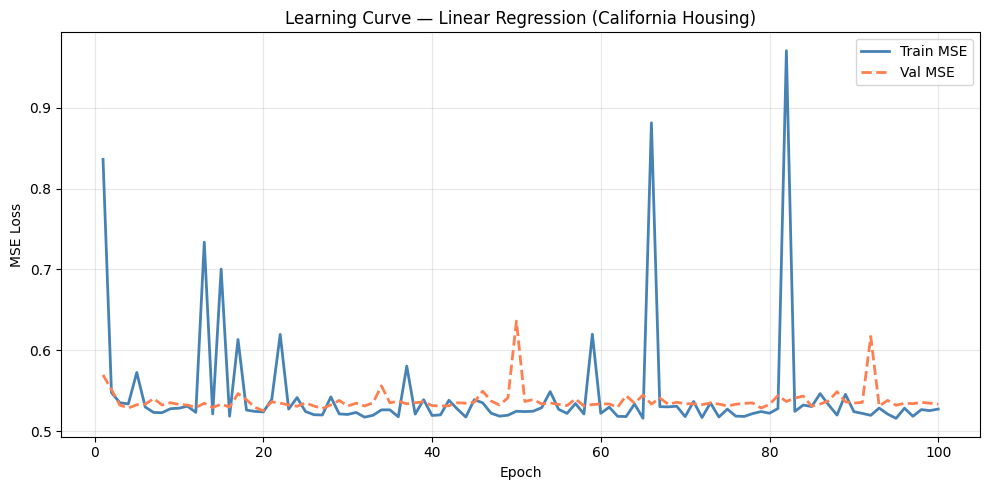

Final Train MSE: 0.5272
Final Val   MSE: 0.5333


In [26]:
plt.figure(figsize=(10, 5))

# range(1, N_EPOCHS+1) creates [1, 2, 3, ..., 100] as the x-axis
# This makes the x-axis read '1' to '100' instead of '0' to '99'
epochs_range = range(1, N_EPOCHS + 1)

plt.plot(epochs_range, train_losses, label='Train MSE', color='steelblue',  linewidth=2)
plt.plot(epochs_range, val_losses,   label='Val MSE',   color='coral',      linewidth=2, linestyle='--')
# linestyle='--' draws the validation curve as a dashed line — easy to distinguish from train

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curve — Linear Regression (California Housing)')
plt.legend()
plt.grid(True, alpha=0.3)  # alpha=0.3 makes the grid lines faint — readable but not distracting
plt.tight_layout()

os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/linear_regression_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final Train MSE: {train_losses[-1]:.4f}')
print(f'Final Val   MSE: {val_losses[-1]:.4f}')

In [27]:
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)

        # .cpu() moves the tensor from GPU back to CPU (needed if using CUDA)
        # .numpy() converts PyTorch tensor to NumPy array
        # .flatten() collapses shape (N, 1) to (N,) — a simple 1D array
        all_preds.append(preds.cpu().numpy().flatten())
        all_true.append(y_batch.numpy().flatten())

# np.concatenate joins a list of arrays into one long array
# e.g. [[1,2], [3,4], [5,6]] → [1, 2, 3, 4, 5, 6]
y_pred_val = np.concatenate(all_preds)
y_true_val = np.concatenate(all_true)

# Compute metrics manually so you understand what they calculate
mse  = np.mean((y_pred_val - y_true_val) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_pred_val - y_true_val))
# MAE = Mean Absolute Error = average of |prediction - truth|
# Less sensitive to large outliers than MSE

print('=== Validation Set Metrics ===')
print(f'  MSE:  {mse:.4f}  (units: $100k squared)')
print(f'  RMSE: {rmse:.4f}  (units: $100k  → multiply by 100,000 for dollars)')
print(f'  MAE:  {mae:.4f}  (units: $100k)')
print()
print(f'  In plain English: predictions are off by ~${rmse*100000:,.0f} on average (RMSE)') 

=== Validation Set Metrics ===
  MSE:  0.5333  (units: $100k squared)
  RMSE: 0.7303  (units: $100k  → multiply by 100,000 for dollars)
  MAE:  0.5365  (units: $100k)

  In plain English: predictions are off by ~$73,028 on average (RMSE)


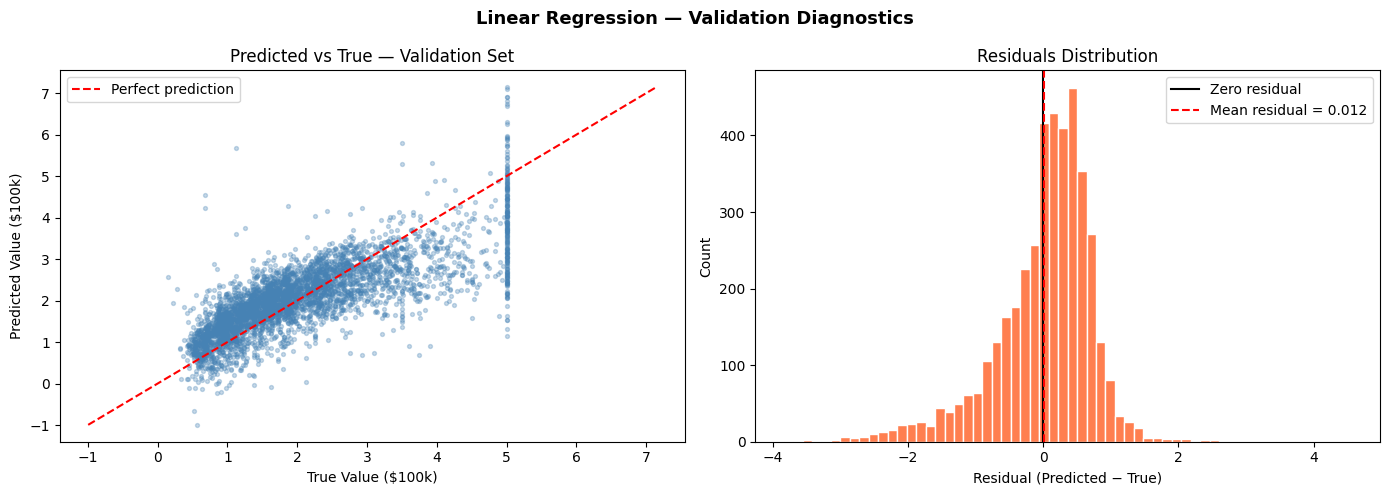

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Predicted vs True scatter plot ---
# A perfect model would put all points exactly on the diagonal line y=x
# Points above the line → model under-predicted
# Points below the line → model over-predicted
axes[0].scatter(y_true_val, y_pred_val, alpha=0.3, s=8, color='steelblue')

# Draw the perfect prediction line y=x
# min and max of the range give us start and end points of the diagonal
lims = [min(y_true_val.min(), y_pred_val.min()),
        max(y_true_val.max(), y_pred_val.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
# 'r--' → red dashed line
axes[0].set_xlabel('True Value ($100k)')
axes[0].set_ylabel('Predicted Value ($100k)')
axes[0].set_title('Predicted vs True — Validation Set')
axes[0].legend()

# --- Plot 2: Residuals histogram ---
# Residual = prediction - truth (how wrong we were, and in which direction)
# A well-behaved model has residuals centred at 0 with roughly Gaussian shape
# Systematic bias (mean ≠ 0) means the model consistently over or under predicts
residuals = y_pred_val - y_true_val
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, label='Zero residual')
axes[1].axvline(residuals.mean(), color='red', linestyle='--',
                label=f'Mean residual = {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Predicted − True)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution')
axes[1].legend()

plt.suptitle('Linear Regression — Validation Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/linear_regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/logs',   exist_ok=True)

# --- Save model weights ---
# model.state_dict() returns a dictionary of all parameter tensors:
#   {'linear.weight': tensor([[w1, w2, ..., w8]]), 'linear.bias': tensor([b])}
# torch.save() serialises this dictionary to a .pth file (PyTorch's native format)
# Convention: name the file to reflect the experiment — useful when you have many models
model_path = '../results/models/linear_regression_california.pth'
torch.save(model.state_dict(), model_path)
print(f'Model saved to: {model_path}')

# --- Log results to CSV ---
# We build one row of results as a dictionary, then append it to a CSV log file.
# This CSV will grow as you run more experiments (polynomial, ridge) — your ablation table.
log_path = '../results/logs/experiment_log.csv'

result_row = {
    'experiment':  'linear_regression',
    'dataset':     'california_housing',
    'model_type':  'OLS',
    'degree_M':    1,              # polynomial degree — 1 for plain linear
    'lambda':      None,           # regularisation strength — None for plain OLS
    'n_epochs':    N_EPOCHS,
    'batch_size':  BATCH_SIZE,
    'lr':          LEARNING_RATE,
    'train_mse':   round(train_losses[-1], 4),
    'val_mse':     round(val_losses[-1],   4),
    'val_rmse':    round(rmse,             4),
    'val_mae':     round(mae,              4),
    'test_mse':    None,           # we do NOT evaluate on test yet — only at the very end
}

# Convert the result row to a single-row DataFrame
result_df = pd.DataFrame([result_row])

# If log file already exists: append without writing a new header
# If log file does not exist yet: create it and write the header
if os.path.exists(log_path):
    result_df.to_csv(log_path, mode='a', header=False, index=False)
    # mode='a'     → append mode: adds rows to the bottom without overwriting
    # header=False → don't write column names again (they already exist in the file)
else:
    result_df.to_csv(log_path, mode='w', header=True, index=False)
    # mode='w'     → write mode: creates the file fresh
    # header=True  → write column names as the first row

print(f'Results logged to: {log_path}')
print()
print('Current experiment log:')
print(pd.read_csv(log_path).to_string())

Model saved to: ../results/models/linear_regression_california.pth
Results logged to: ../results/logs/experiment_log.csv

Current experiment log:
          experiment             dataset model_type  degree_M  lambda  n_epochs  batch_size    lr  train_mse  val_mse  val_rmse  val_mae  test_mse
0  linear_regression  california_housing        OLS         1     NaN       100          32  0.01     0.5272   0.5333    0.7303   0.5365       NaN


In [30]:
from sklearn.datasets import fetch_california_housing as _fetch
feature_names = _fetch().feature_names

# Extract learned weights from the model
# .detach() stops gradient tracking — we just want the values, not to compute gradients
# .numpy() converts to NumPy for easy display
weights = model.linear.weight.detach().numpy().flatten()  # shape (8,)
bias    = model.linear.bias.detach().numpy()[0]           # scalar

print('Learned model parameters after training:')
print(f'  Bias (b): {bias:.4f}')
print()
print('  Feature weights (sorted by absolute value):')

# Zip feature names with their weights and sort by absolute magnitude
weight_df = pd.DataFrame({'feature': feature_names, 'weight': weights})
weight_df['abs_weight'] = weight_df['weight'].abs()
weight_df = weight_df.sort_values('abs_weight', ascending=False).drop(columns='abs_weight')
print(weight_df.to_string(index=False))
print()
print('The feature with the largest absolute weight has the most influence on predictions.')
print('Does the top feature match what you expected from the correlation heatmap in EDA?')

# --- Bar chart of weights ---
plt.figure(figsize=(9, 4))
colours = ['steelblue' if w > 0 else 'coral' for w in weight_df['weight']]
# Positive weights → blue (feature pushes price up)
# Negative weights → red  (feature pushes price down)
plt.bar(weight_df['feature'], weight_df['weight'], color=colours, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Feature')
plt.ylabel('Learned Weight')
plt.title('Linear Regression — Learned Feature Weights')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/plots/linear_regression_weights.png', dpi=150, bbox_inches='tight')
plt.show()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.